# 🌱 Análisis Exploratorio de la Base de Datos de Plantas

Este notebook realiza un EDA completo sobre la base de datos actual del proyecto de clasificación de enfermedades de plantas. Se analiza la estructura moderna: variables `planta` y `enfermedad` separadas, imágenes en varios formatos y fuentes, y se ofrecen visualizaciones y recomendaciones para el modelado.

## 1. Importación de librerías necesarias


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import os
from collections import Counter
from glob import glob

# Opcional: para análisis avanzado o conexión a MongoDB
# from pymongo import MongoClient
# import requests

sns.set_theme(style="whitegrid")

## 2. Carga y exploración inicial de los datos

Consultamos directamente la base de datos MongoDB para obtener toda la información de las imágenes. Esto permite analizar el estado real y completo del dataset antes de cualquier experimento.

Los campos disponibles por imagen son:
- `_id`: identificador único
- `imagen_rgb`: ruta local a la imagen
- `validada`: si la imagen ha sido validada
- `clase`: diccionario con las claves `planta` y `enfermedad`
- `fuente`: fuente de la imagen
- `formato`: formato de la imagen (Color, Grayscale, Segmented)

In [3]:
from pymongo import MongoClient
import pandas as pd
import numpy as np

client = MongoClient("mongodb://localhost:27017/")
db = client["Repositorio_Plantas"]

# Cargar docs
raw_docs = list(db["Docs"].find())
df = pd.DataFrame(raw_docs)

# Cargar diccionarios de mapeo para clase, fuente y formato
clases_dict = {c['_id']: c for c in db['Clases'].find()}
fuentes_dict = {f['_id']: f['fuente'] for f in db['Fuente'].find()}
formatos_dict = {f['_id']: f['formato'] for f in db['Formato'].find()}

# Añadir columnas descriptivas de clase
for campo in ['planta', 'clasificacion', 'nombre_comun', 'nombre_cientifico']:
    df[campo] = df['clase'].map(lambda cid: clases_dict[cid][campo] if cid in clases_dict else None)
    df[campo] = df[campo].replace("", np.nan)
# Para fuente y formato: nombre
if 'fuente' in df.columns:
    df['fuente_nombre'] = df['fuente'].map(lambda fid: fuentes_dict.get(fid, str(fid)))
    df['fuente_nombre'] = df['fuente_nombre'].replace("", np.nan)
if 'formato' in df.columns:
    df['formato_nombre'] = df['formato'].map(lambda fid: formatos_dict.get(fid, str(fid)))
    df['formato_nombre'] = df['formato_nombre'].replace("", np.nan)

print(f"Total de imágenes en la base de datos: {len(df)}")
display(df.head())
print("\nColumnas disponibles:", list(df.columns))

Total de imágenes en la base de datos: 163101


C:\Users\Pablo\AppData\Local\Temp\ipykernel_8868\4192589223.py:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[campo] = df[campo].replace("", np.nan)


,_id,imagen_rgb,validada,clase,fuente,formato,planta,clasificacion,nombre_comun,nombre_cientifico,fuente_nombre,formato_nombre
0,685814c6602b3d9871e1a85a,http://158.42.184.169:5001/imagen_base64/b7487...,False,0,0,0,Apple,NaN,Apple_scab,NaN,PlantVillage,Color
1,685814c6602b3d9871e1a85b,http://158.42.184.169:5001/imagen_base64/ded6f...,False,0,0,0,Apple,NaN,Apple_scab,NaN,PlantVillage,Color
2,685814c6602b3d9871e1a85c,http://158.42.184.169:5001/imagen_base64/5cc37...,False,0,0,0,Apple,NaN,Apple_scab,NaN,PlantVillage,Color
3,685814c6602b3d9871e1a85d,http://158.42.184.169:5001/imagen_base64/166a7...,False,0,0,0,Apple,NaN,Apple_scab,NaN,PlantVillage,Color
4,685814c6602b3d9871e1a85e,http://158.42.184.169:5001/imagen_base64/501d2...,False,0,0,0,Apple,NaN,Apple_scab,NaN,PlantVillage,Color



Columnas disponibles: ['_id', 'imagen_rgb', 'validada', 'clase', 'fuente', 'formato', 'planta', 'clasificacion', 'nombre_comun', 'nombre_cientifico', 'fuente_nombre', 'formato_nombre']


## 3. Distribución de imágenes por planta, enfermedad, formato y fuente

Visualizamos la cantidad de imágenes por cada variable clave para detectar posibles desbalances y entender la diversidad del dataset.

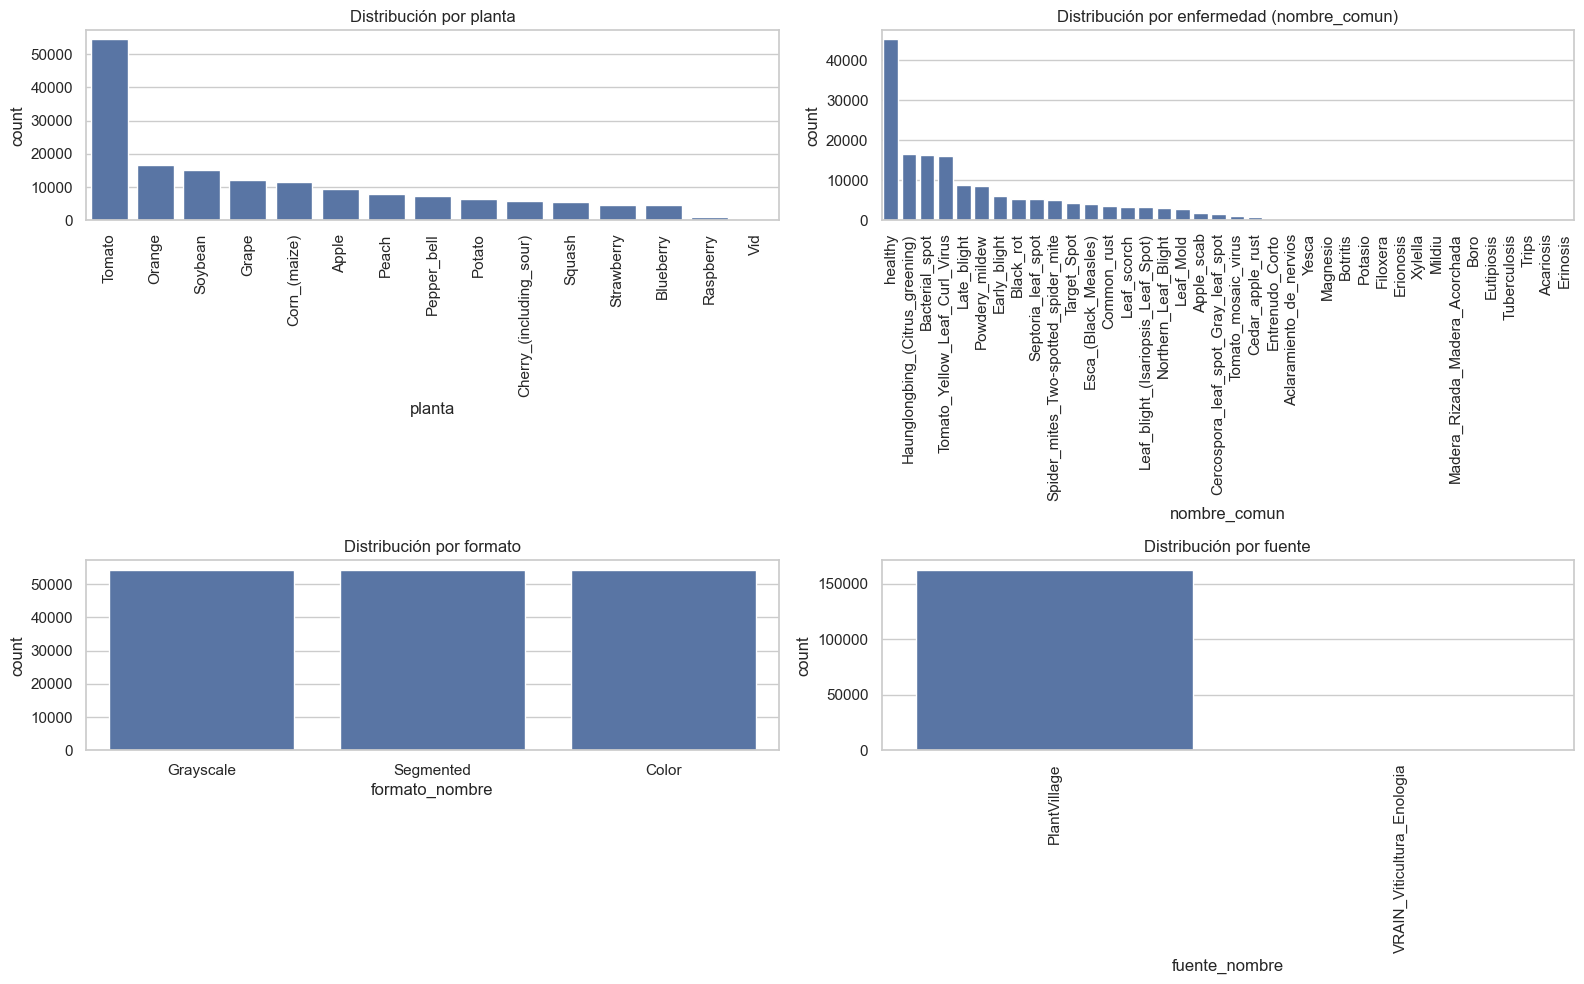

In [4]:
fig, axs = plt.subplots(2, 2, figsize=(16, 10))

# Planta
if df['planta'].notna().any():
    sns.countplot(data=df, x='planta', order=df['planta'].value_counts().index, ax=axs[0,0])
    axs[0,0].set_title('Distribución por planta')
    axs[0,0].tick_params(axis='x', rotation=90)
else:
    axs[0,0].set_visible(False)

# Enfermedad (nombre_comun)
if df['nombre_comun'].notna().any():
    sns.countplot(data=df, x='nombre_comun', order=df['nombre_comun'].value_counts().index, ax=axs[0,1])
    axs[0,1].set_title('Distribución por enfermedad (nombre_comun)')
    axs[0,1].tick_params(axis='x', rotation=90)
else:
    axs[0,1].set_visible(False)

# Formato
if df['formato_nombre'].notna().any():
    sns.countplot(data=df, x='formato_nombre', order=df['formato_nombre'].value_counts().index, ax=axs[1,0])
    axs[1,0].set_title('Distribución por formato')
else:
    axs[1,0].set_visible(False)

# Fuente
if df['fuente_nombre'].notna().any():
    sns.countplot(data=df, x='fuente_nombre', order=df['fuente_nombre'].value_counts().index, ax=axs[1,1])
    axs[1,1].set_title('Distribución por fuente')
    axs[1,1].tick_params(axis='x', rotation=90)
else:
    axs[1,1].set_visible(False)

plt.tight_layout()
plt.show()

Como sabemos, la diferencia entre la cantidad de imágenes de cada fuente es abismal. Vamos a mirarlas por separado.

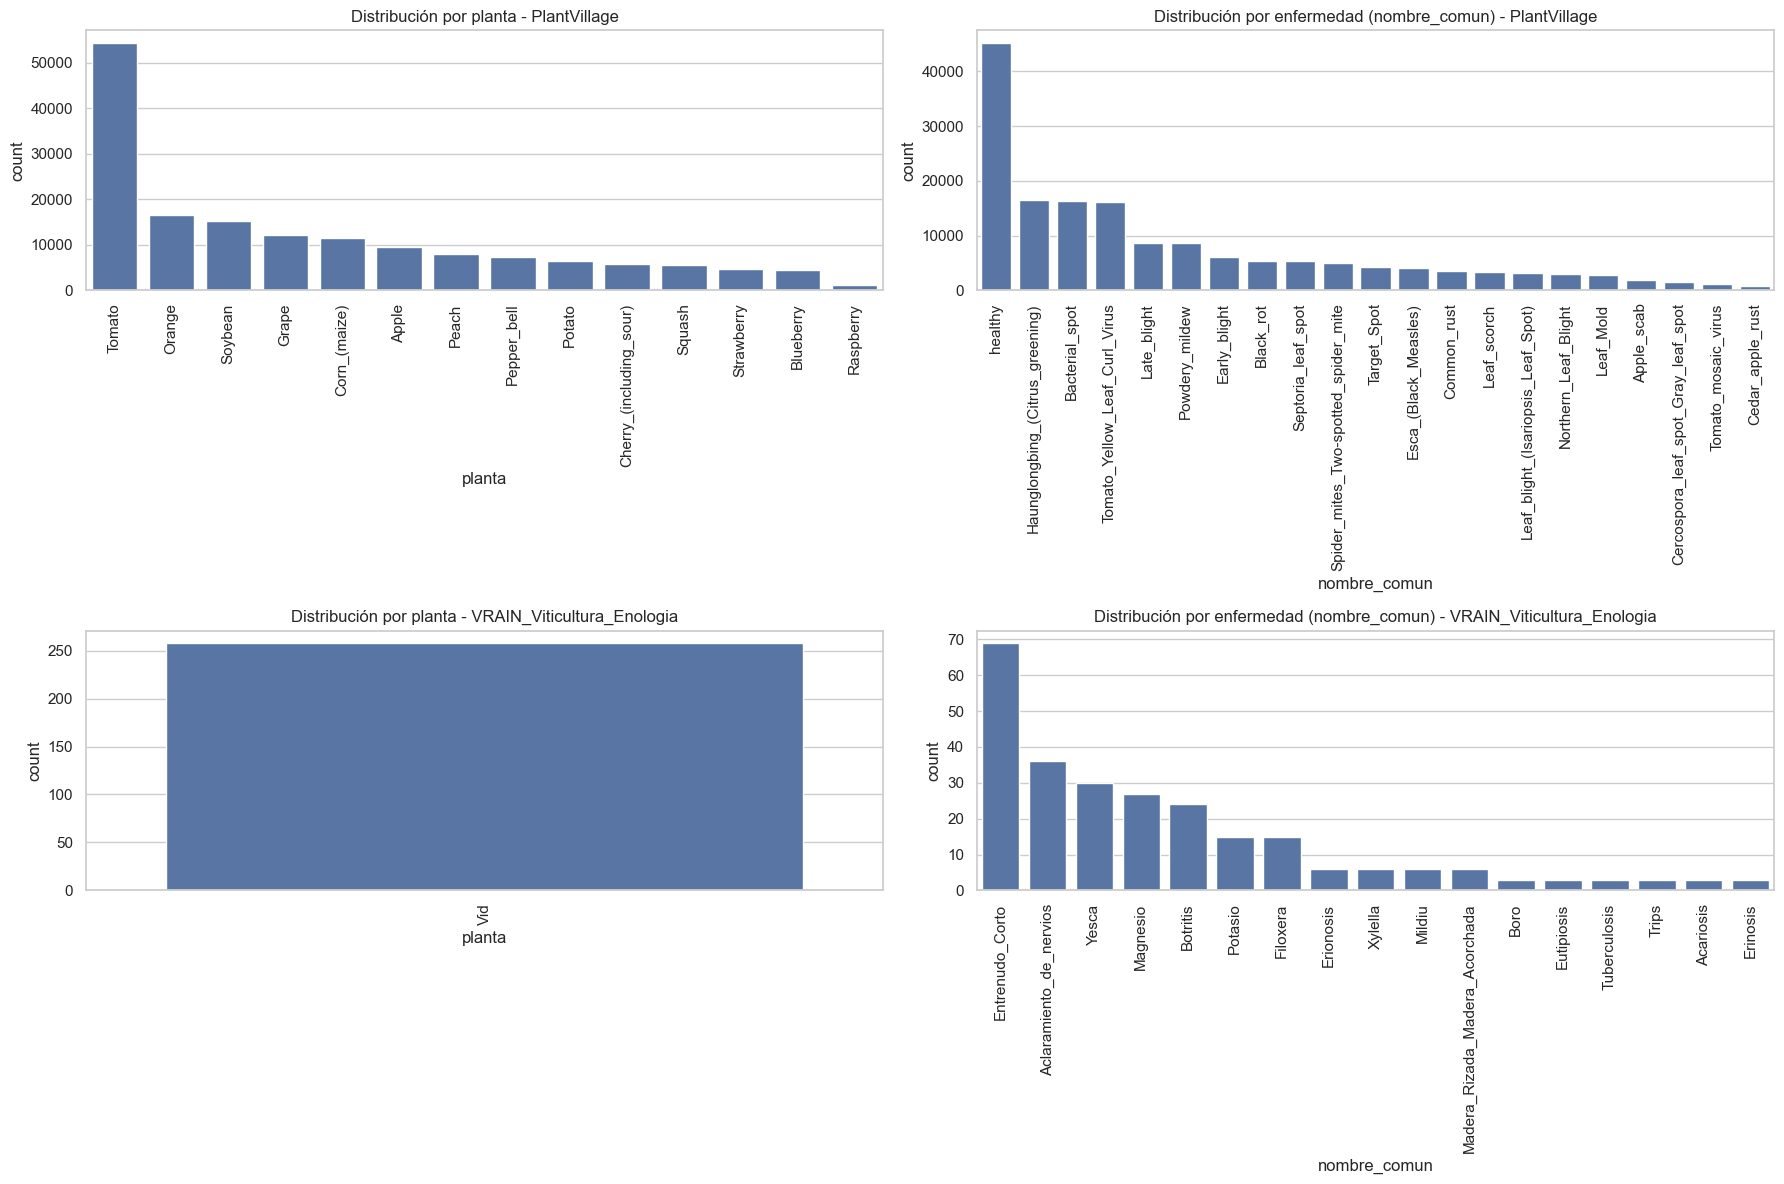

In [5]:
# Gráficos separados por fuente para evitar escalas desproporcionadas
fuentes = df['fuente_nombre'].dropna().unique()
fig, axs = plt.subplots(len(fuentes), 2, figsize=(18, 6*len(fuentes)))
if len(fuentes) == 1:
    axs = axs.reshape(1, 2)

for i, fuente in enumerate(fuentes):
    subdf = df[df['fuente_nombre'] == fuente]
    # Distribución por planta
    if subdf['planta'].notna().any():
        sns.countplot(data=subdf, x='planta', order=subdf['planta'].value_counts().index, ax=axs[i,0])
        axs[i,0].set_title(f"Distribución por planta - {fuente}")
        axs[i,0].tick_params(axis='x', rotation=90)
    else:
        axs[i,0].set_visible(False)
    # Distribución por enfermedad (nombre_comun)
    if subdf['nombre_comun'].notna().any():
        sns.countplot(data=subdf, x='nombre_comun', order=subdf['nombre_comun'].value_counts().index, ax=axs[i,1])
        axs[i,1].set_title(f"Distribución por enfermedad (nombre_comun) - {fuente}")
        axs[i,1].tick_params(axis='x', rotation=90)
    else:
        axs[i,1].set_visible(False)

plt.tight_layout()
plt.show()

## 4. Análisis de correlación planta-enfermedad

Exploramos la relación entre plantas y enfermedades: qué combinaciones existen, cuáles son más frecuentes y si hay combinaciones ausentes o raras.

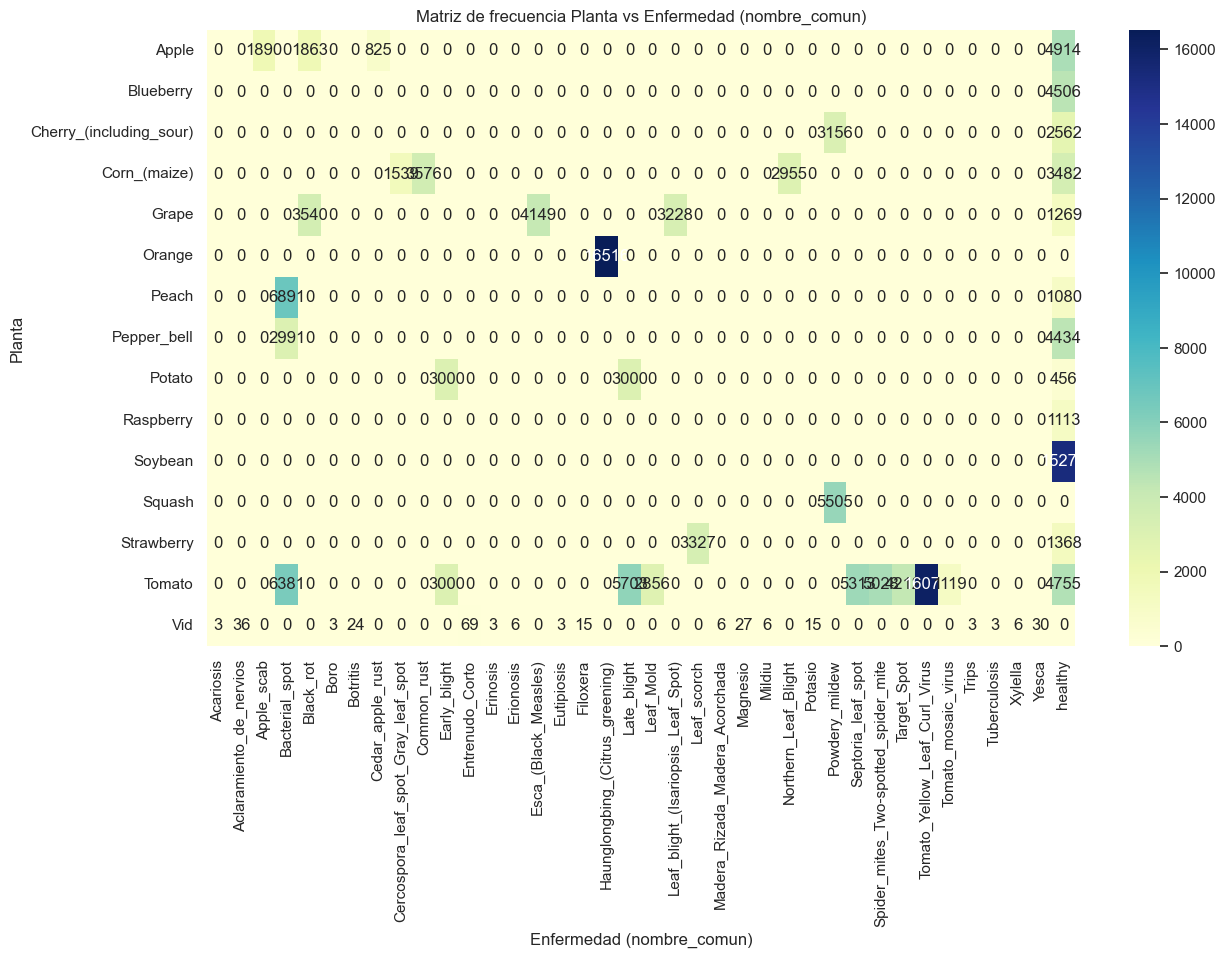

In [7]:
pivot = df.pivot_table(index='planta', columns='nombre_comun', values='imagen_rgb', aggfunc='count', fill_value=0)
plt.figure(figsize=(14,8))
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Matriz de frecuencia Planta vs Enfermedad (nombre_comun)')
plt.ylabel('Planta')
plt.xlabel('Enfermedad (nombre_comun)')
plt.show()

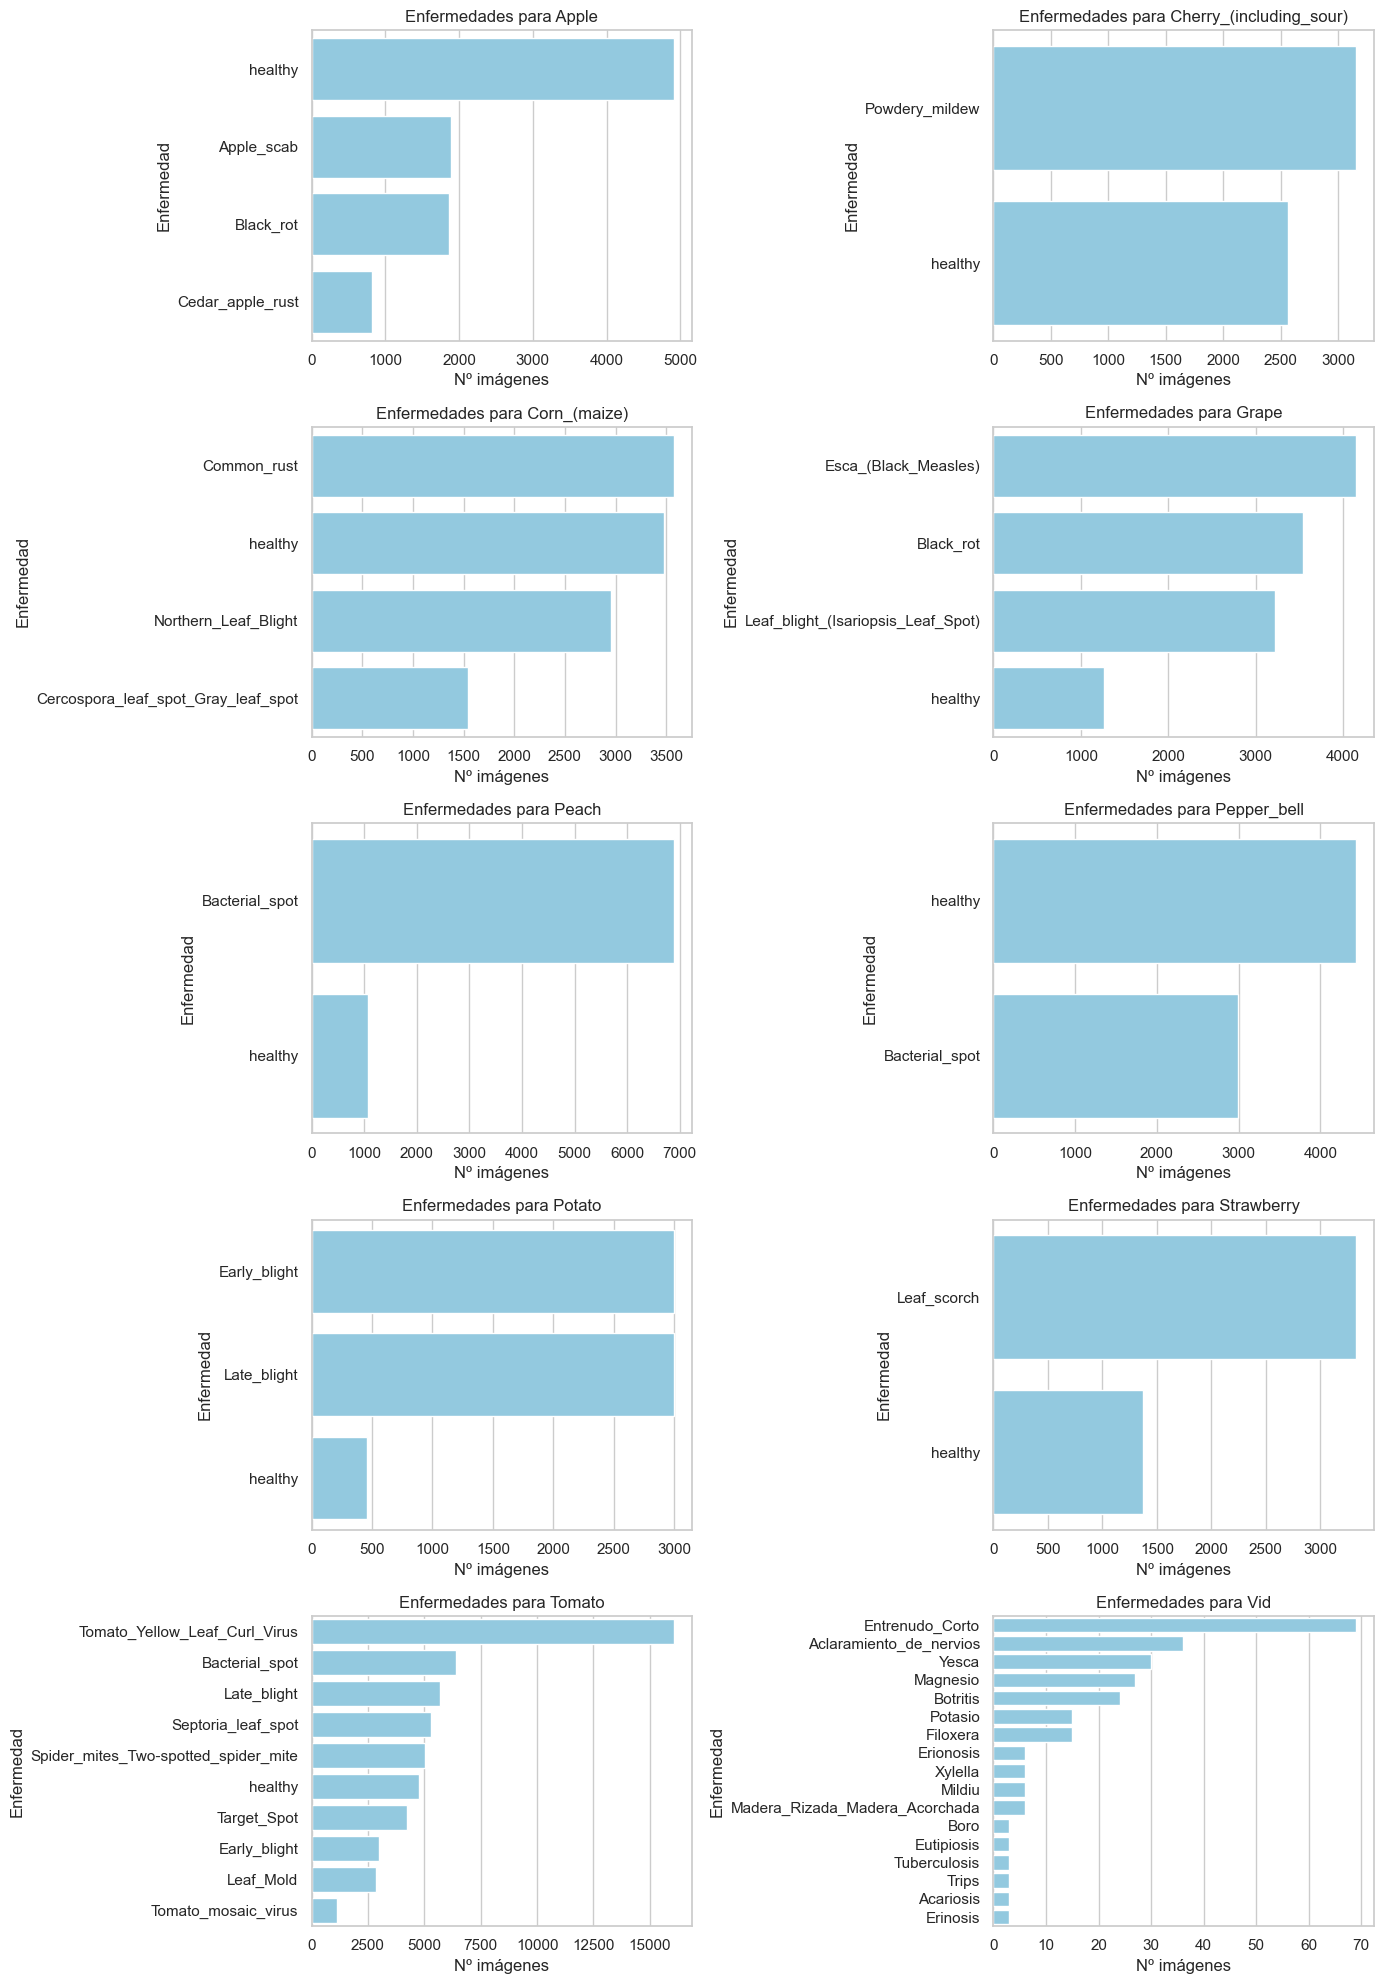

Plantas con solo una enfermedad (no se muestran en la gráfica): Blueberry, Orange, Raspberry, Soybean, Squash


In [10]:
# Visualización: Enfermedades posibles por planta (solo combinaciones existentes, solo si hay más de una enfermedad, barras horizontales para mejor legibilidad)
plantas = df['planta'].dropna().unique()
# Filtrar plantas con más de una enfermedad
plantas_validas = [pl for pl in plantas if df[df['planta'] == pl]['nombre_comun'].nunique() > 1]
if len(plantas_validas) == 0:
    print("Ninguna planta tiene más de una enfermedad asociada.")
else:
    n = len(plantas_validas)
    ncols = 2
    nrows = (n + ncols - 1) // ncols
    fig, axs = plt.subplots(nrows, ncols, figsize=(14, 4*nrows), sharex=False)
    axs = axs.flatten()
    for i, planta in enumerate(plantas_validas):
        subdf = df[df['planta'] == planta]
        counts = subdf['nombre_comun'].value_counts()
        sns.barplot(y=counts.index, x=counts.values, ax=axs[i], color='skyblue')
        axs[i].set_title(f'Enfermedades para {planta}')
        axs[i].set_xlabel('Nº imágenes')
        axs[i].set_ylabel('Enfermedad')
    # Eliminar ejes vacíos si los hay
    for j in range(i+1, len(axs)):
        fig.delaxes(axs[j])
    plt.tight_layout()
    plt.show()
    # Mencionar las plantas con solo una enfermedad
    plantas_una = [pl for pl in plantas if df[df['planta'] == pl]['nombre_comun'].nunique() == 1]
    if plantas_una:
        print("Plantas con solo una enfermedad (no se muestran en la gráfica):", ', '.join(plantas_una))

## 5. Detección de clases y fuentes desbalanceadas

Identificamos clases (planta/enfermedad) o fuentes con pocas imágenes, lo que puede afectar al entrenamiento y evaluación de los modelos.

In [14]:
min_imgs = 50  # Umbral de ejemplo
clase_counts = df.groupby(['planta', 'nombre_comun']).size().reset_index(name='count')
clases_pocas = clase_counts[clase_counts['count'] < min_imgs]
print(f"Clases (planta, nombre_comun) con menos de {min_imgs} imágenes:")
display(clases_pocas)

fuente_counts = df['fuente_nombre'].value_counts()
print("\nFuentes con menos de 500 imágenes:")
display(fuente_counts[fuente_counts < 500])

Clases (planta, nombre_comun) con menos de 50 imágenes:


,planta,nombre_comun,count
38,Vid,Acariosis,3
39,Vid,Aclaramiento_de_nervios,36
40,Vid,Boro,3
41,Vid,Botritis,24
43,Vid,Erinosis,3
44,Vid,Erionosis,6
45,Vid,Eutipiosis,3
46,Vid,Filoxera,15
47,Vid,Madera_Rizada_Madera_Acorchada,6
48,Vid,Magnesio,27



Fuentes con menos de 500 imágenes:


fuente_nombre
VRAIN_Viticultura_Enologia    258
Name: count, dtype: int64

In [21]:
# Análisis de desbalanceo solo con imágenes de PlantVillage
df_pv = df[df['fuente_nombre'] == 'PlantVillage']
print(f"Total de imágenes de PlantVillage: {len(df_pv)}")
min_imgs = 1500  # Umbral de ejemplo
clase_counts_pv = df_pv.groupby(['planta', 'nombre_comun']).size().reset_index(name='count')
clases_pocas_pv = clase_counts_pv[clase_counts_pv['count'] < min_imgs]
print(f"Clases (planta, nombre_comun) con menos de {min_imgs} imágenes en PlantVillage:")
display(clases_pocas_pv)

Total de imágenes de PlantVillage: 162843
Clases (planta, nombre_comun) con menos de 1500 imágenes en PlantVillage:


,planta,nombre_comun,count
2,Apple,Cedar_apple_rust,825
14,Grape,healthy,1269
17,Peach,healthy,1080
22,Potato,healthy,456
23,Raspberry,healthy,1113
27,Strawberry,healthy,1368
36,Tomato,Tomato_mosaic_virus,1119
